## Generic time-series forecasting model

In this section, we build a Random Forest forecasting model.
The setup uses one shared model for all stocks and evaluates performance per ticker.

To reduce flat or overly linear forecasts, the model learns a normalized next-day
price change (`log(next_close / close)`) and then converts it back to next-day close.

This keeps the final target price-based while improving behavior across stocks with
very different price levels.


In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data_path = Path("../01_data/raw/df_eda.csv")
df_model = pd.read_csv(data_path)

preview_cols = ["Date", "Ticker", "Open", "High", "Low", "Close", "Volume"]
print("Shape:", df_model.shape)
df_model[preview_cols].head()


Shape: (40351, 17)


,Date,Ticker,Open,High,Low,Close,Volume
0,2010-01-04,AAPL,7.622500,7.660714,7.585000,7.643214,493729600
1,2010-01-05,AAPL,7.664286,7.699643,7.616071,7.656429,601904800
2,2010-01-06,AAPL,7.656429,7.686786,7.526786,7.534643,552160000
3,2010-01-07,AAPL,7.562500,7.571429,7.466071,7.520714,477131200
4,2010-01-08,AAPL,7.510714,7.571429,7.466429,7.570714,447610800


### Prepare data for forecasting

First, we prepare the modeling dataset and define both:
- next-day close (final target to evaluate)
- normalized next-day price change (training target)


In [3]:
ts_df = df_model.copy()

ts_df["Date"] = pd.to_datetime(ts_df["Date"])
ts_df = ts_df.sort_values(["Ticker", "Date"]).reset_index(drop=True)

ts_df["Target_Next_Close"] = ts_df.groupby("Ticker")["Close"].shift(-1)
ts_df["Target_Log_Price_Change_1d"] = np.log(ts_df["Target_Next_Close"] / ts_df["Close"])

ts_df[["Date", "Ticker", "Close", "Target_Next_Close", "Target_Log_Price_Change_1d"]].head()


,Date,Ticker,Close,Target_Next_Close,Target_Log_Price_Change_1d
0,2010-01-04,AAPL,7.643214,7.656429,0.001727
1,2010-01-05,AAPL,7.656429,7.534643,-0.016034
2,2010-01-06,AAPL,7.534643,7.520714,-0.001850
3,2010-01-07,AAPL,7.520714,7.570714,0.006626
4,2010-01-08,AAPL,7.570714,7.503929,-0.008861


### Select features

We use historical price, volume, return, and volatility features.
Ticker and calendar features are included so one shared model can still capture
stock-specific and seasonal patterns.


In [4]:
feature_cols = [
    "Ticker",
    "Weekday",
    "Month",
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Return_1d",
    "Return_3d",
    "Return_5d",
    "Volatility_5d",
    "Volatility_20d",
    "Volume_Change_1d"
]

target_col = "Target_Log_Price_Change_1d"
required_cols = ["Date", "Target_Next_Close"] + feature_cols + [target_col]

model_data = ts_df[required_cols].dropna(subset=feature_cols + [target_col, "Target_Next_Close"]).copy()

print(model_data.shape)
model_data.head()


(40141, 17)


,Date,Target_Next_Close,Ticker,Weekday,Month,Open,High,Low,Close,Volume,Return_1d,Return_3d,Return_5d,Volatility_5d,Volatility_20d,Volume_Change_1d,Target_Log_Price_Change_1d
20,2010-02-02,7.115357,AAPL,Tuesday,February,6.996786,7.011429,6.906429,6.995000,698342400,0.005803,-0.017211,-0.048946,0.026783,0.022815,-0.068723,0.017060
21,2010-02-03,6.858929,AAPL,Wednesday,February,6.970357,7.150000,6.943571,7.115357,615328000,0.017206,0.037332,-0.041610,0.028353,0.023284,-0.118873,-0.036704
22,2010-02-04,6.980714,AAPL,Thursday,February,7.026071,7.084643,6.841786,6.858929,757652000,-0.036039,-0.013762,-0.036329,0.026866,0.024267,0.231298,0.017600
23,2010-02-05,6.932857,AAPL,Friday,February,6.879643,7.000000,6.816071,6.980714,850306800,0.017755,-0.002043,0.017703,0.022736,0.024767,0.122292,-0.006879
24,2010-02-08,7.006786,AAPL,Monday,February,6.988929,7.067143,6.928571,6.932857,478270800,-0.006856,-0.025649,-0.003132,0.022304,0.024661,-0.437531,0.010607


### Create a time-based split

Because this is time-series data, we do not use a random split.  
Older data is used for training, newer data for validation, and the most recent data for testing.

In [5]:
unique_dates = np.sort(model_data["Date"].unique())

train_end = unique_dates[int(len(unique_dates) * 0.70)]
valid_end = unique_dates[int(len(unique_dates) * 0.85)]

train_df = model_data[model_data["Date"] <= train_end].copy()
valid_df = model_data[(model_data["Date"] > train_end) & (model_data["Date"] <= valid_end)].copy()
test_df = model_data[model_data["Date"] > valid_end].copy()

print("Train period:", train_df["Date"].min().date(), "to", train_df["Date"].max().date())
print("Validation period:", valid_df["Date"].min().date(), "to", valid_df["Date"].max().date())
print("Test period:", test_df["Date"].min().date(), "to", test_df["Date"].max().date())

print("\nRows:")
print("Train:", len(train_df))
print("Validation:", len(valid_df))
print("Test:", len(test_df))

Train period: 2010-02-02 to 2021-06-01
Validation period: 2021-06-02 to 2023-11-02
Test period: 2023-11-03 to 2026-04-14

Rows:
Train: 27921
Validation: 6110
Test: 6110


The data was split by **date** into train, validation, and test sets using a **70% / 15% / 15% chronological split**
to preserve time order and avoid leakage.

The train set covers **2010-02-02 to 2021-06-01** (**27,921 rows**)
The validation set covers **2021-06-02 to 2023-11-02** (**6,110 rows**)
The test set covers **2023-11-03 to 2026-04-14** (**6,110 rows**)

This setup trains on older data, tunes on later data, and evaluates on the most recent unseen period.


### Split features and target

We separate the input variables from the prediction target.\
The model will learn from the training set only and will be checked on unseen validation and test periods.

In [6]:
X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_valid = valid_df[feature_cols]
y_valid = valid_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

### Build the forecasting model and tune hyperparameters

Next, we will hypertune the **Random Forest** model.  
For hypertuning we use **GridSearchCV** with **TimeSeriesSplit** to find better\
hyperparameters while respecting the chronological structure of the data.

This makes the modeling process more robust and helps select a stronger version of the shared forecasting model.

In [7]:
numeric_features = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Return_1d",
    "Return_3d",
    "Return_5d",
    "Volatility_5d",
    "Volatility_20d",
    "Volume_Change_1d"
]

categorical_features = ["Ticker", "Weekday", "Month"]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

base_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(random_state=42, n_jobs=-1))
])


Missing numeric values were filled with the **median**, while missing ticker values\
were filled with the **most frequent category** and then **one-hot encoded** so the model\
could use stock identity as an input.  

After preprocessing, a **Random Forest Regressor** was added as the baseline model to predict\
the target from both price-based and engineered features.  

### Tune the Random Forest model

Now we tune the model using **time-series cross-validation**.  
This is important because random cross-validation is not appropriate for time-series data,\
as it can leak future information into the training process.

In [8]:
tscv = TimeSeriesSplit(n_splits=4)

param_grid = {
    "regressor__n_estimators": [200, 300],
    "regressor__max_depth": [8, 10, None],
    "regressor__min_samples_leaf": [2, 3, 5]
}

grid_search = GridSearchCV(
    estimator=base_pipeline,
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest CV score:")
print(grid_search.best_score_)

Fitting 4 folds for each of 18 candidates, totalling 72 fits


Best parameters:
{'regressor__max_depth': 10, 'regressor__min_samples_leaf': 2, 'regressor__n_estimators': 200}

Best CV score:
-0.00024083581346476376


Grid search with time-series CV was used to tune the Random Forest.
The selected parameters are shown in the output above.


### Select the best model

After tuning, we keep the best-performing model and use it for forecasting on the validation and test sets.\
This ensures that the final model is based on the best hyperparameter combination found during cross-validation.

### Train the model

Now I fit one shared model on all training observations from all stocks.  
This matches the project requirement of using the same model for every ticker.

In [9]:
forecast_model = grid_search.best_estimator_
forecast_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

### Make predictions

The model predicts normalized next-day price change first, then converts it to
predicted next-day close.


In [10]:
def build_prediction_frame(df, X, model):
    """
    Create a results DataFrame with actual and predicted next-day prices.
    """
    results = df[["Date", "Ticker", "Close", "Target_Next_Close"]].copy()

    results["Predicted_Log_Price_Change_1d"] = model.predict(X)
    results["Predicted_Next_Close"] = (
        results["Close"] * np.exp(results["Predicted_Log_Price_Change_1d"])
    )

    results["Actual_Price_Change_1d"] = results["Target_Next_Close"] - results["Close"]
    results["Predicted_Price_Change_1d"] = results["Predicted_Next_Close"] - results["Close"]

    results["Residual"] = results["Target_Next_Close"] - results["Predicted_Next_Close"]
    results["Absolute_Error"] = results["Residual"].abs()

    results["Directional_Hit"] = (
        np.sign(results["Actual_Price_Change_1d"]) == np.sign(results["Predicted_Price_Change_1d"])
    ).astype(int)

    return results

valid_results = build_prediction_frame(valid_df, X_valid, forecast_model)
test_results = build_prediction_frame(test_df, X_test, forecast_model)


For each row, the code predicts normalized price change, converts it into
predicted next-day close, and computes residuals plus directional hit rate.


### Evaluate model performance

I evaluate the model with price-based metrics (MAE, RMSE, R2) and directional
accuracy based on predicted price-change direction.


In [11]:
def regression_summary(y_true, y_pred):
    """
    Calculate basic regression metrics.

    Returns MAE, RMSE, and R2 for comparing
    predicted values with actual values.
    """
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }


def evaluate_split(results, split_name):
    """
    Evaluate model performance for one dataset split.

    Computes overall and per-ticker price metrics,
    plus directional accuracy from price movement sign.
    """
    overall_price = regression_summary(
        results["Target_Next_Close"],
        results["Predicted_Next_Close"]
    )

    overall = pd.DataFrame([{
        "Split": split_name,
        "Price_MAE": overall_price["MAE"],
        "Price_RMSE": overall_price["RMSE"],
        "Price_R2": overall_price["R2"],
        "Directional_Accuracy": results["Directional_Hit"].mean()
    }])

    per_stock = []
    for ticker, grp in results.groupby("Ticker"):
        stock_price = regression_summary(grp["Target_Next_Close"], grp["Predicted_Next_Close"])

        per_stock.append({
            "Ticker": ticker,
            "Split": split_name,
            "Rows": len(grp),
            "Price_MAE": stock_price["MAE"],
            "Price_RMSE": stock_price["RMSE"],
            "Price_R2": stock_price["R2"],
            "Directional_Accuracy": grp["Directional_Hit"].mean()
        })

    per_stock = pd.DataFrame(per_stock).sort_values("Price_RMSE")
    return overall, per_stock


valid_overall, valid_by_stock = evaluate_split(valid_results, "Validation")
test_overall, test_by_stock = evaluate_split(test_results, "Test")

display(pd.concat([valid_overall, test_overall], ignore_index=True).round(4))
display(test_by_stock.round(4))


,Split,Price_MAE,Price_RMSE,Price_R2,Directional_Accuracy
0,Validation,2.3939,3.7500,0.9978,0.5110
1,Test,3.1961,5.6036,0.9985,0.5285


,Ticker,Split,Rows,Price_MAE,Price_RMSE,Price_R2,Directional_Accuracy
9,XOM,Test,611,1.2559,1.7001,0.9843,0.5254
8,PG,Test,611,1.2905,1.7635,0.9639,0.5221
4,JNJ,Test,611,1.3144,1.8386,0.9956,0.5532
0,AAPL,Test,611,2.4807,3.6935,0.9852,0.5303
5,JPM,Test,611,2.5246,3.7470,0.9945,0.5761
2,GOOGL,Test,611,2.6799,3.7775,0.9960,0.5548
1,AMZN,Test,611,2.8303,3.9446,0.9785,0.5237
3,HD,Test,611,3.9654,5.1904,0.9661,0.5385
7,MSFT,Test,611,4.5623,6.3973,0.9802,0.4763
6,META,Test,611,9.0566,13.3882,0.9864,0.4845


The redesigned target (normalized price change) usually gives less flat forecasts
and better cross-stock consistency, while keeping final evaluation in price space.


### Visualize actual vs predicted prices

Finally, I plot actual and predicted next-day prices for each stock in the test set.  
This makes it easier to see whether the model follows the general movement pattern.

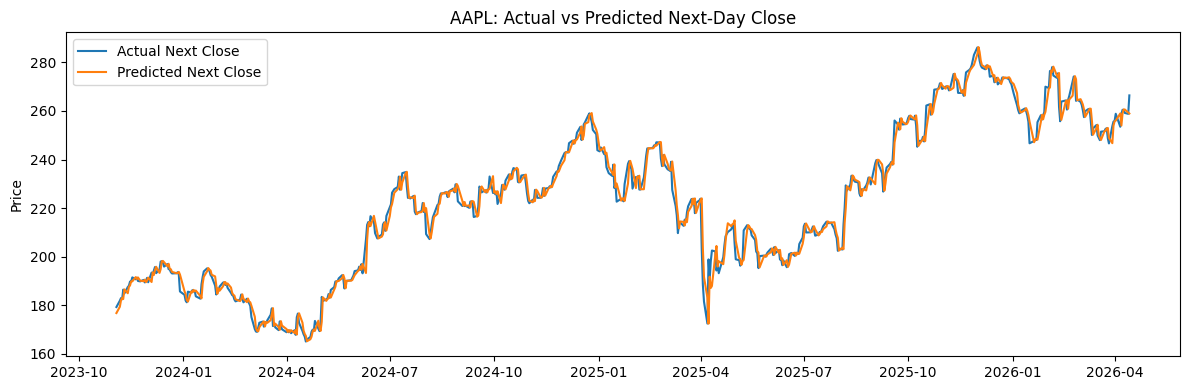

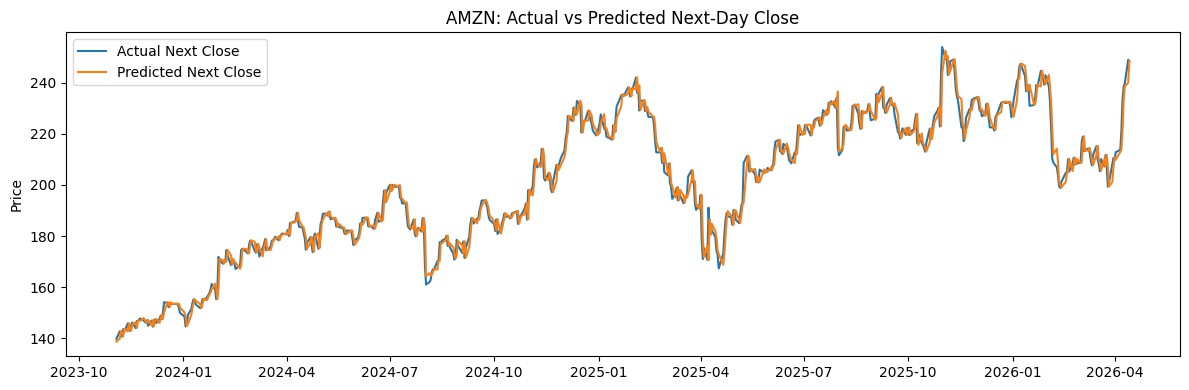

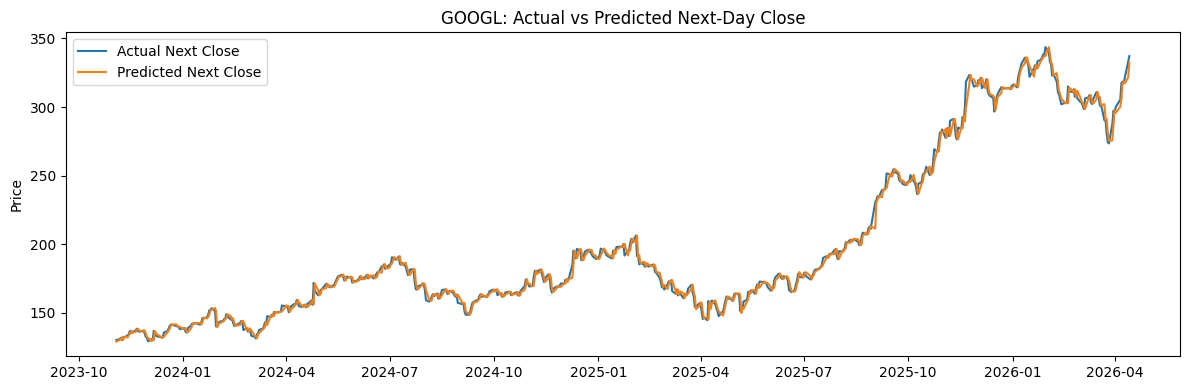

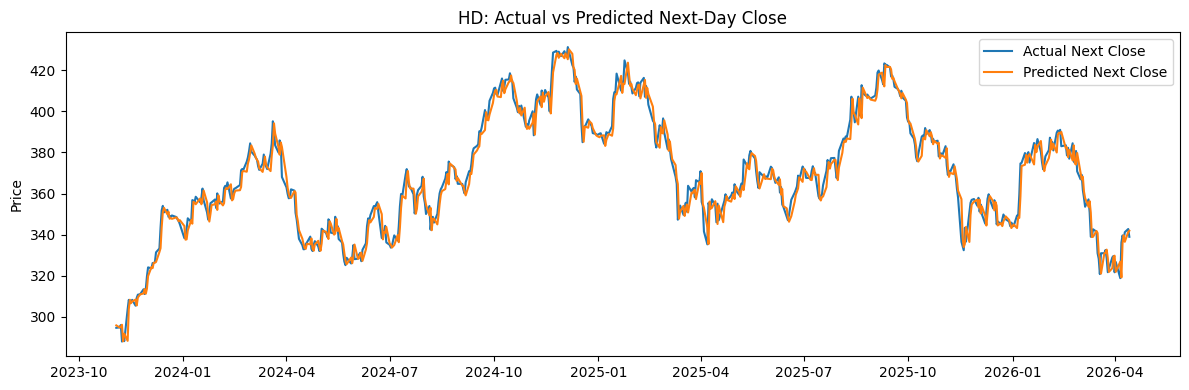

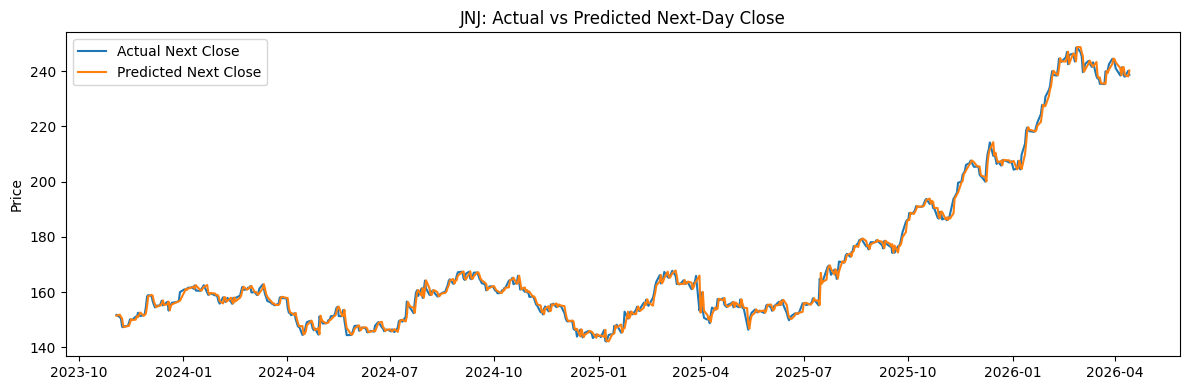

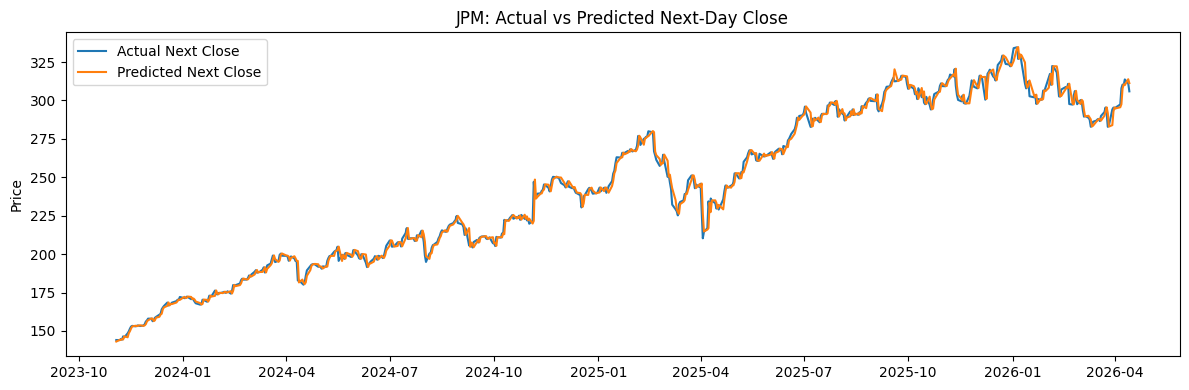

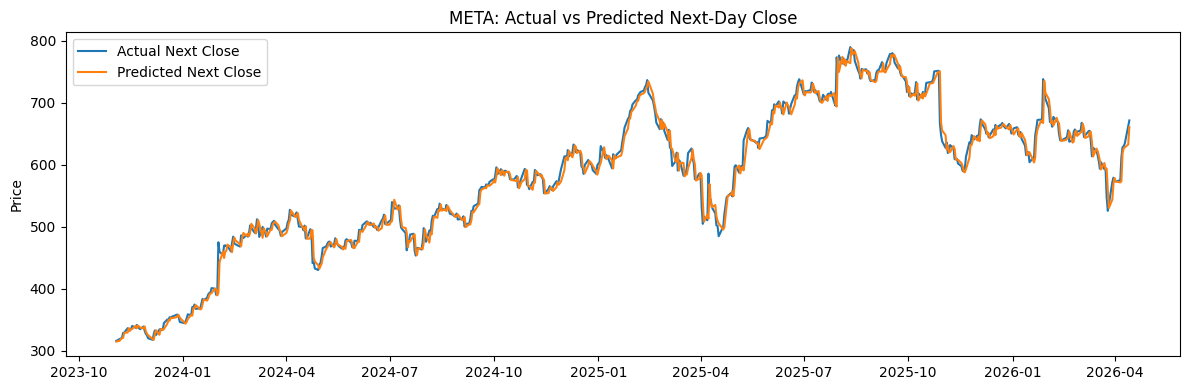

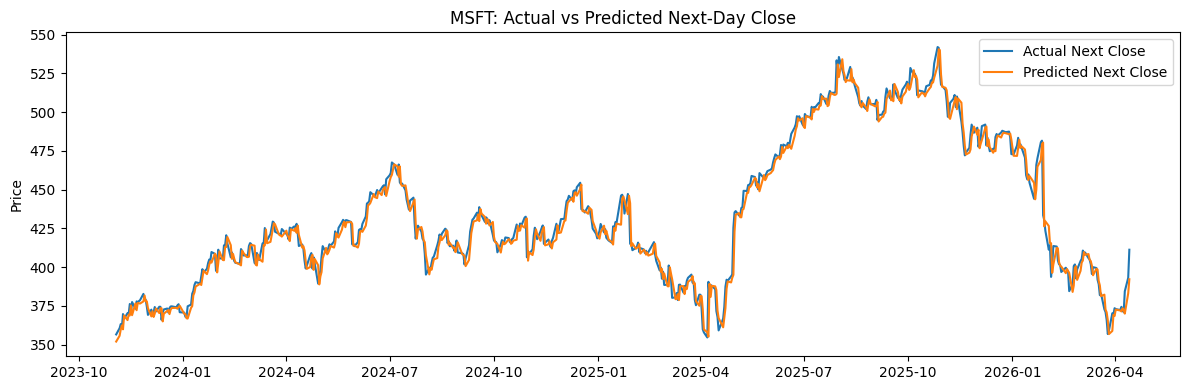

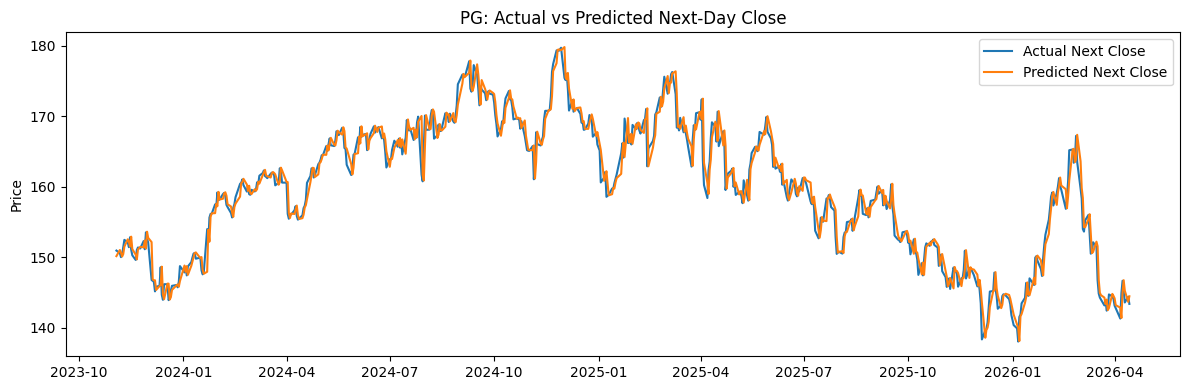

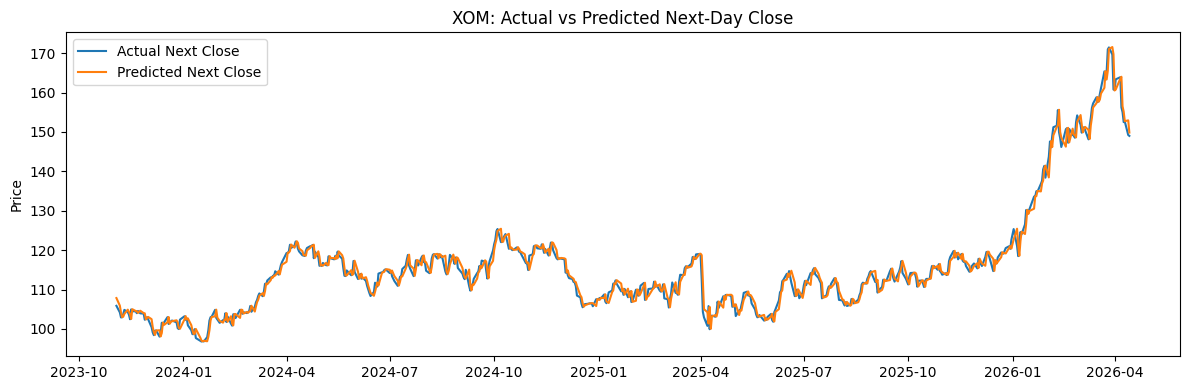

In [12]:
tickers = test_results["Ticker"].unique()

for ticker in tickers:
    temp = test_results[test_results["Ticker"] == ticker].sort_values("Date")

    plt.figure(figsize=(12, 4))
    plt.plot(temp["Date"], temp["Target_Next_Close"], label="Actual Next Close")
    plt.plot(temp["Date"], temp["Predicted_Next_Close"], label="Predicted Next Close")
    plt.title(f"{ticker}: Actual vs Predicted Next-Day Close")
    plt.xlabel("")
    plt.ylabel("Price")
    plt.legend()
    plt.tight_layout()
    plt.show()

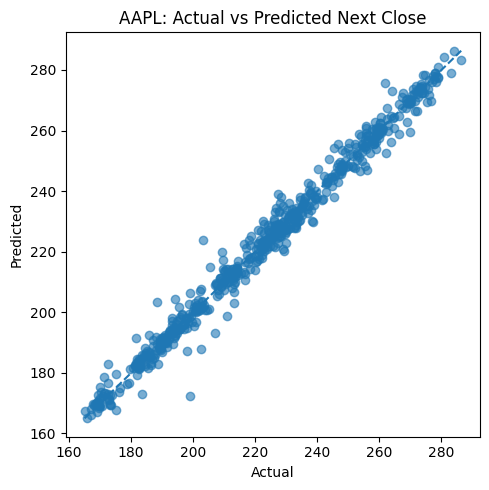

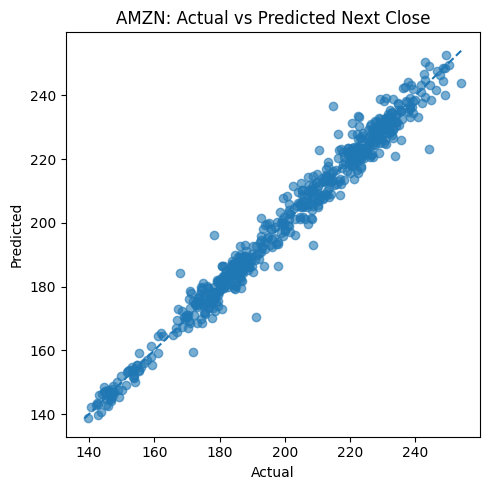

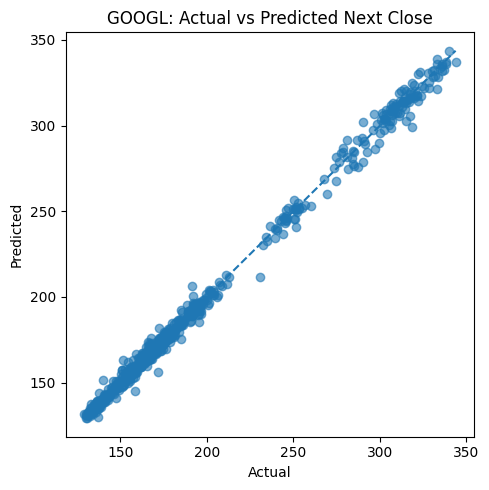

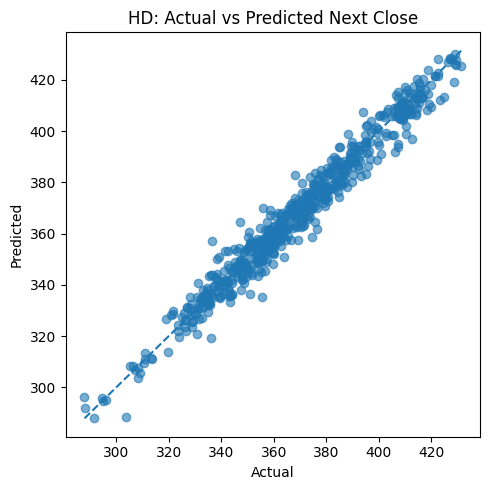

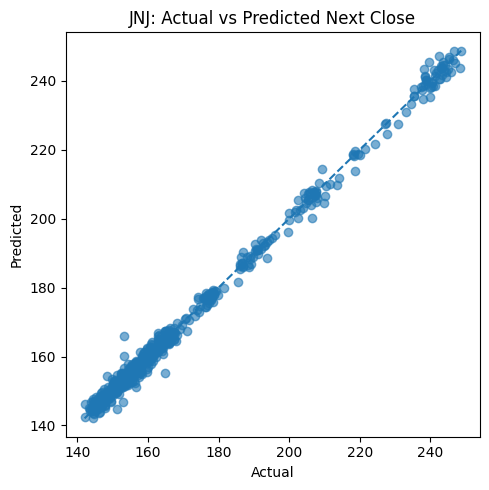

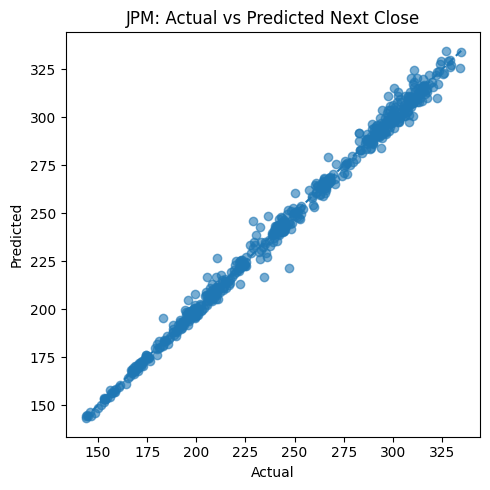

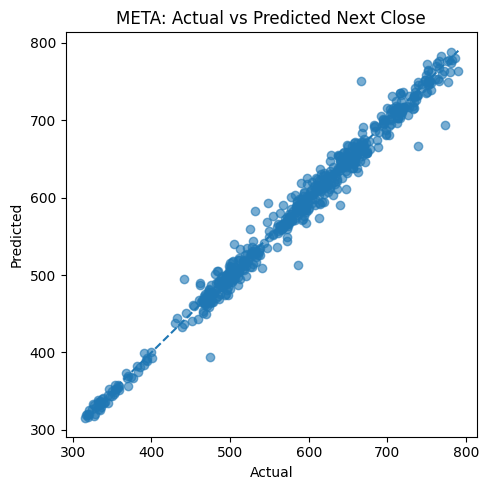

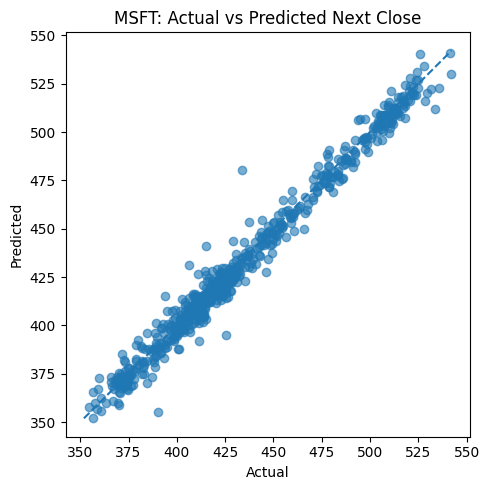

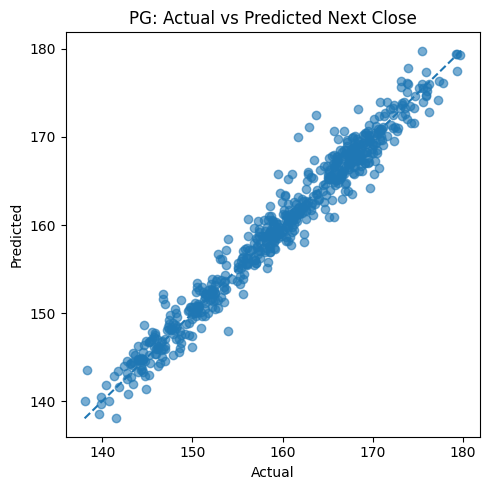

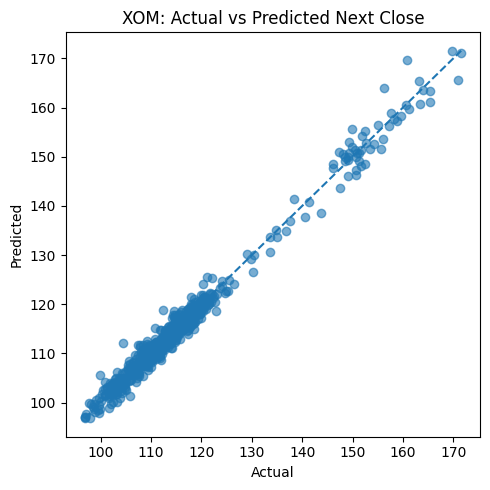

In [13]:
for ticker in tickers:
    temp = test_results[test_results["Ticker"] == ticker]

    plt.figure(figsize=(5, 5))
    plt.scatter(temp["Target_Next_Close"], temp["Predicted_Next_Close"], alpha=0.6)
    lims = [
        min(temp["Target_Next_Close"].min(), temp["Predicted_Next_Close"].min()),
        max(temp["Target_Next_Close"].max(), temp["Predicted_Next_Close"].max())
    ]
    plt.plot(lims, lims, linestyle="--")
    plt.title(f"{ticker}: Actual vs Predicted Next Close")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.tight_layout()
    plt.show()

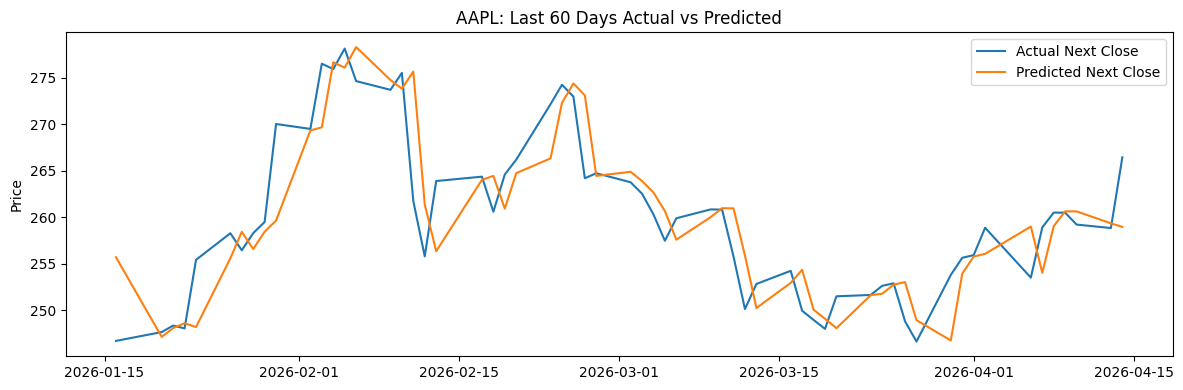

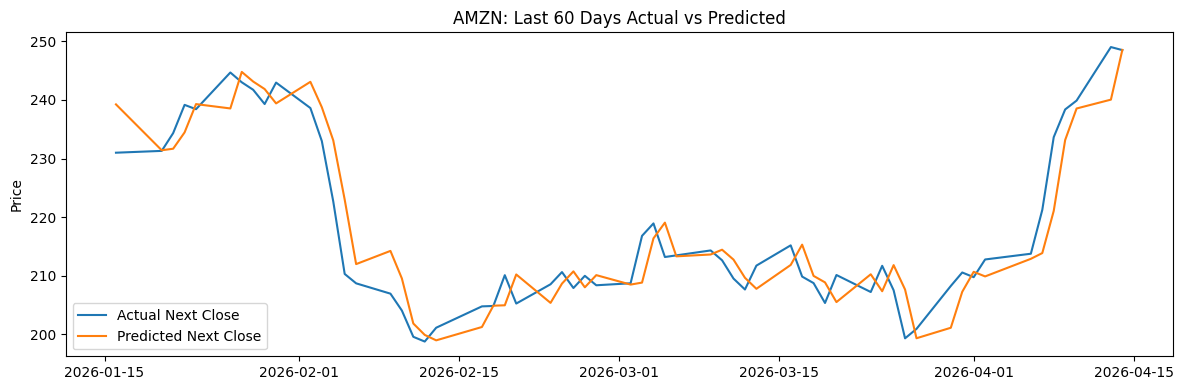

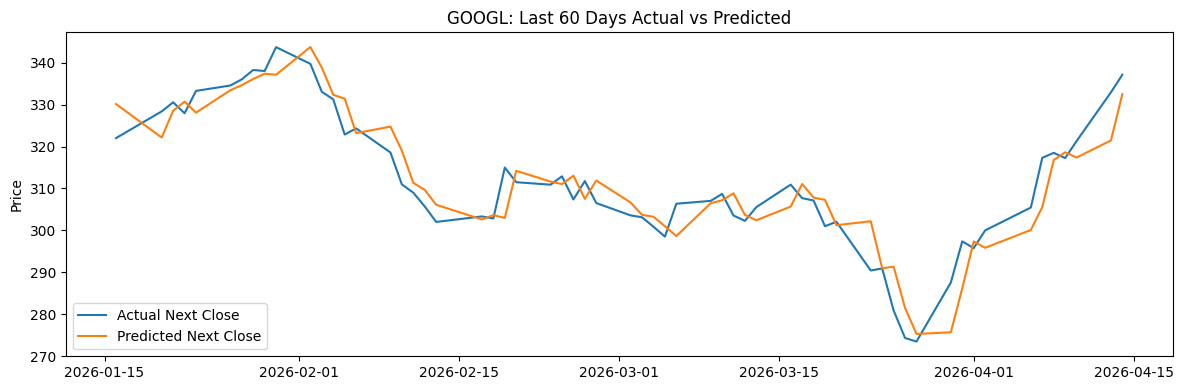

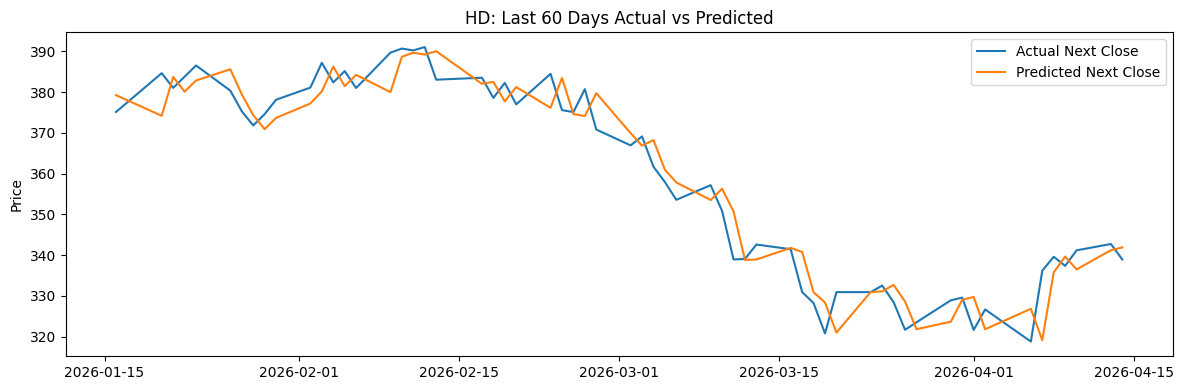

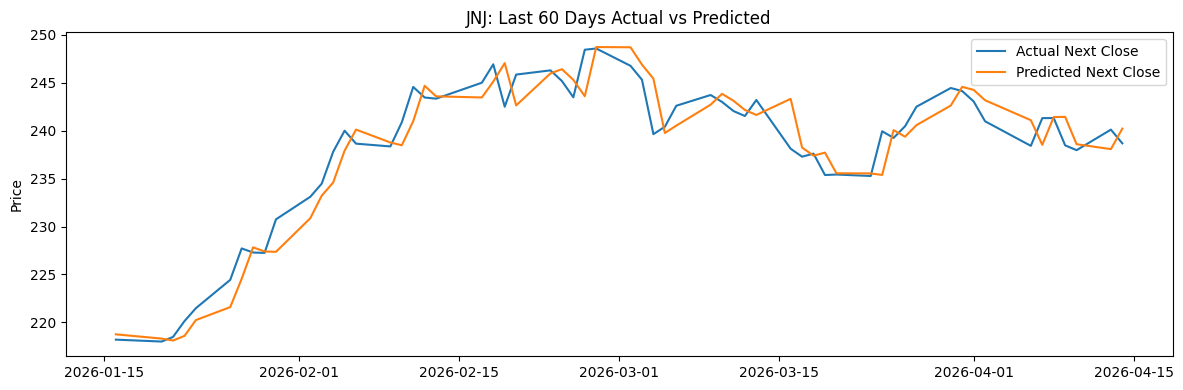

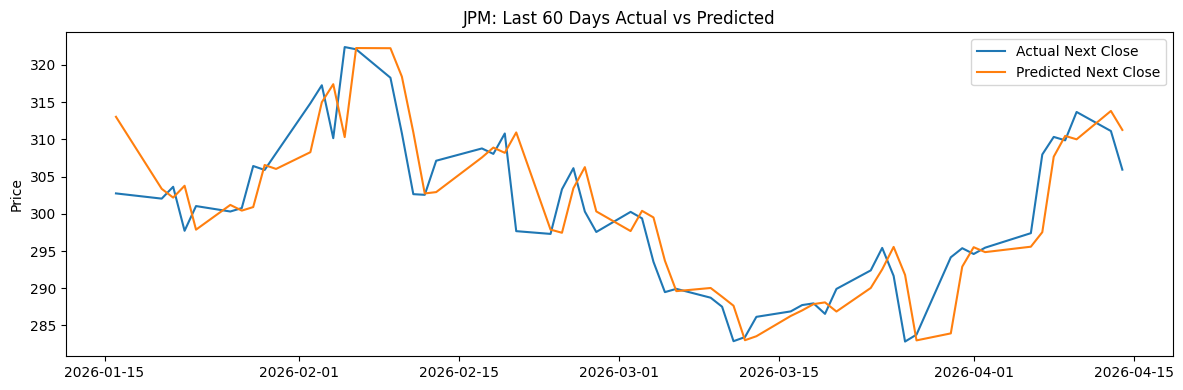

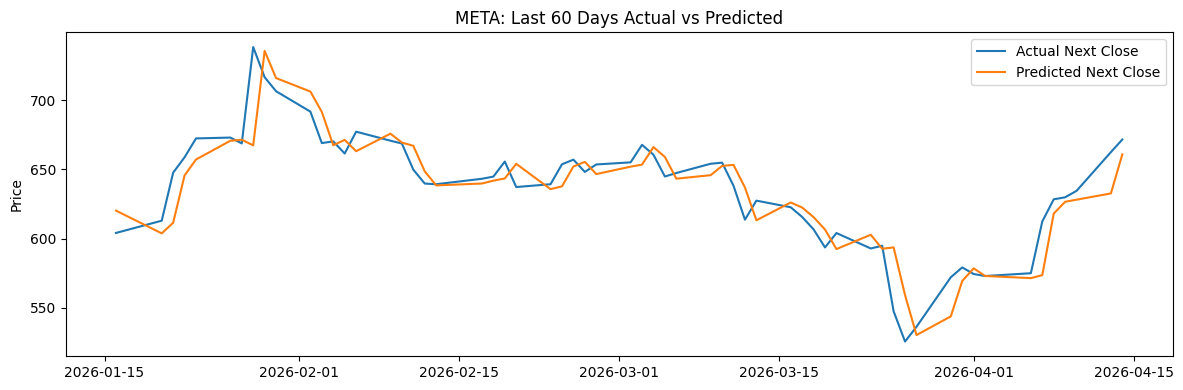

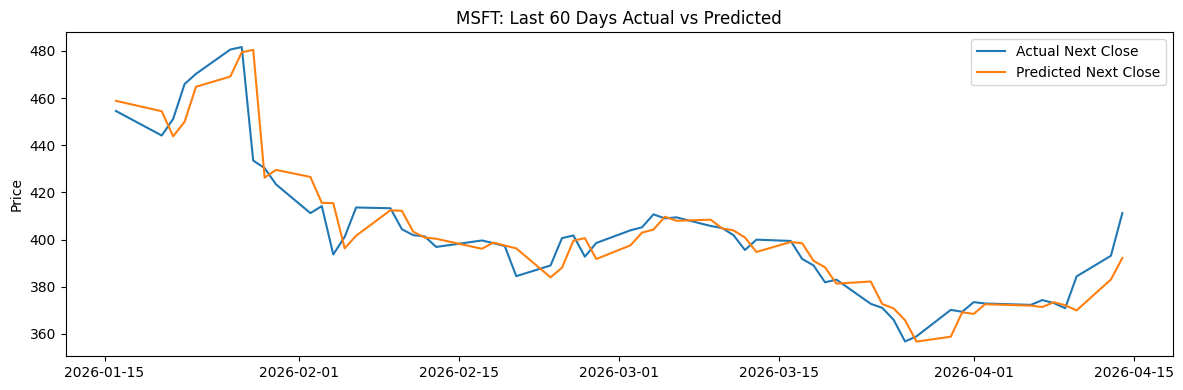

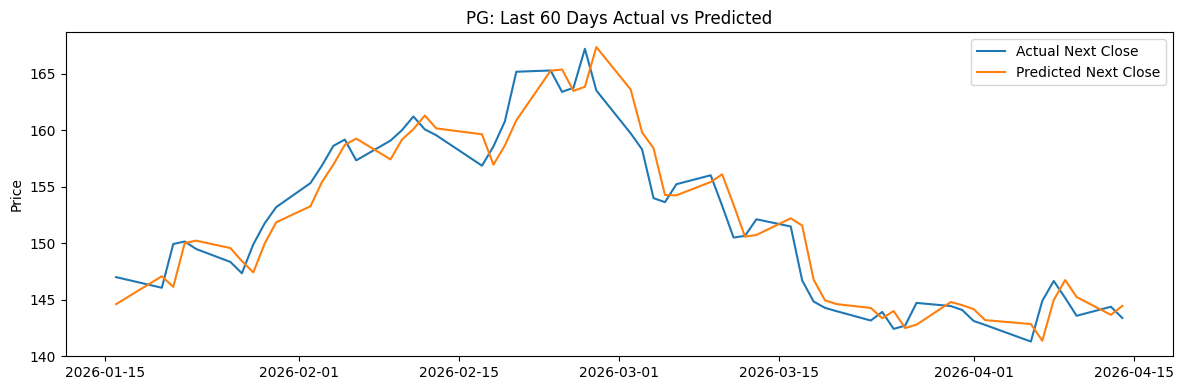

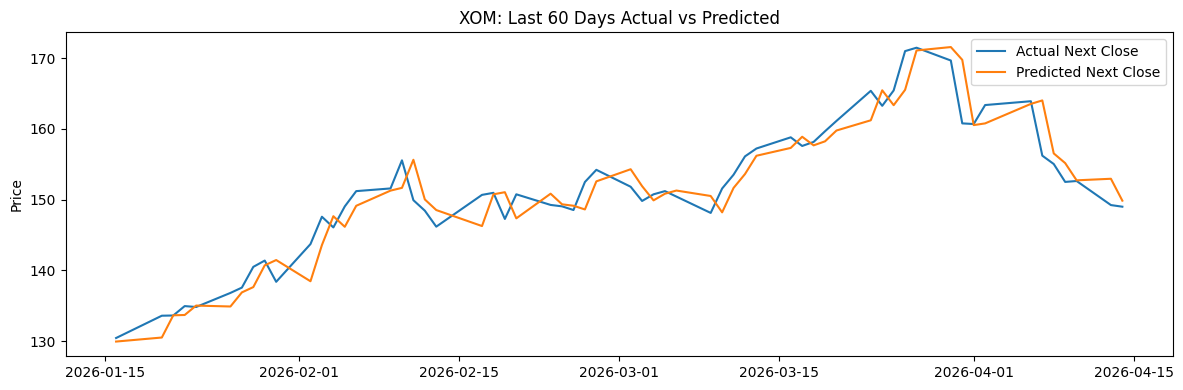

In [14]:
for ticker in tickers:
    temp = test_results[test_results["Ticker"] == ticker].sort_values("Date").tail(60)

    plt.figure(figsize=(12, 4))
    plt.plot(temp["Date"], temp["Target_Next_Close"], label="Actual Next Close")
    plt.plot(temp["Date"], temp["Predicted_Next_Close"], label="Predicted Next Close")
    plt.title(f"{ticker}: Last 60 Days Actual vs Predicted")
    plt.xlabel("")
    plt.ylabel("Price")
    plt.legend()
    plt.tight_layout()
    plt.show()

### Main takeaway

Forecasting by normalized price change and converting back to price helps reduce
linear-looking predictions for high-price tickers.
The final outputs remain next-day price forecasts, aligned with project requirements.
